Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


Upload Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving iplauction2023.csv to iplauction2023.csv


Load Dataset

In [ ]:
df = pd.read_csv("iplauction2023.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


View First 5 Rows

In [ ]:
df.head()

,Unnamed: 0,name,player style,nationality,base price (in lacs),final price (in lacs),franchise,status
0,0,Harshit Rana,Bowler,India,20.0,20.0,KKR,RETAINED
1,1,Ekant Sen,Batter,India,20.0,150.0,CSK,UNSOLD
2,2,Wayne Parnell,Allrounder,South Africa,75.0,150.0,CSK,UNSOLD
3,3,Shakib Al Hasan,Allrounder,Bangladesh,150.0,150.0,KKR,SOLD
4,4,Joe Root,Batter,England,100.0,100.0,RR,SOLD


Rename the Columns

In [ ]:
df = df.rename(columns={
    "name": "Player",
    "player style": "Role",
    "franchise": "Team",
    "base price (in lacs)": "Base Price",
    "final price (in lacs)": "Auction Price",
    "status": "Status"
})

print("Columns Renamed Successfully")

Columns Renamed Successfully


Check Column Names

In [ ]:
print("Column Names:\n")
print(df.columns)

Column Names:

Index(['Unnamed: 0', 'Player', 'Role', 'nationality', 'Base Price',
       'Auction Price', 'Team', 'Status'],
      dtype='object')


Remove Unnecessary Column

In [ ]:
df.drop("Unnamed: 0", axis=1, inplace=True)

print("Unnecessary Column Removed Successfully")

Unnecessary Column Removed Successfully


Display First 5 Records

In [ ]:
print("FIRST FIVE RECORDS\n")
df.head()

FIRST FIVE RECORDS



,Player,Role,nationality,Base Price,Auction Price,Team,Status
0,Harshit Rana,Bowler,India,20.0,20.0,KKR,RETAINED
1,Ekant Sen,Batter,India,20.0,150.0,CSK,UNSOLD
2,Wayne Parnell,Allrounder,South Africa,75.0,150.0,CSK,UNSOLD
3,Shakib Al Hasan,Allrounder,Bangladesh,150.0,150.0,KKR,SOLD
4,Joe Root,Batter,England,100.0,100.0,RR,SOLD


Display Last 5 Records

In [ ]:
print("LAST FIVE RECORDS\n")
df.tail()

LAST FIVE RECORDS



,Player,Role,nationality,Base Price,Auction Price,Team,Status
304,MS Dhoni,WK-Batter,India,20.0,1200.0,CSK,RETAINED
305,Moeen Ali,Allrounder,England,20.0,800.0,CSK,RETAINED
306,Ruturaj Gaikwad,Batter,India,20.0,600.0,CSK,RETAINED
307,Rishabh Pant,WK-Batter,India,20.0,1600.0,DC,RETAINED
308,Axar Patel,Allrounder,India,20.0,900.0,DC,RETAINED


Dataset Shape

In [ ]:
print("DATASET SHAPE")
print(df.shape)

print("\nTOTAL NUMBER OF ROWS :", df.shape[0])
print("TOTAL NUMBER OF COLUMNS :", df.shape[1])

DATASET SHAPE
(309, 7)

TOTAL NUMBER OF ROWS : 309
TOTAL NUMBER OF COLUMNS : 7


Column Names

In [ ]:
print("COLUMN NAMES\n")
print(df.columns.tolist())

COLUMN NAMES

['Player', 'Role', 'nationality', 'Base Price', 'Auction Price', 'Team', 'Status']


Data Types

In [ ]:
print("DATA TYPES\n")
print(df.dtypes)

DATA TYPES

Player            object
Role              object
nationality       object
Base Price       float64
Auction Price    float64
Team              object
Status            object
dtype: object


Dataset Information

In [ ]:
print("DATASET INFORMATION\n")
df.info()

DATASET INFORMATION

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Player         309 non-null    object 
 1   Role           309 non-null    object 
 2   nationality    309 non-null    object 
 3   Base Price     309 non-null    float64
 4   Auction Price  309 non-null    float64
 5   Team           309 non-null    object 
 6   Status         309 non-null    object 
dtypes: float64(2), object(5)
memory usage: 17.0+ KB


Numerical Data Summary

In [ ]:
print("NUMERICAL DATA SUMMARY\n")
print(df.describe())

NUMERICAL DATA SUMMARY

       Base Price  Auction Price
count  309.000000     309.000000
mean    39.158576     317.961165
std     46.047732     404.499312
min     20.000000      20.000000
25%     20.000000      50.000000
50%     20.000000     150.000000
75%     20.000000     400.000000
max    200.000000    1850.000000


Complete Dataset Summary

In [ ]:
print("COMPLETE DATA SUMMARY\n")
print(df.describe(include="all"))

COMPLETE DATA SUMMARY

            Player    Role nationality  Base Price  Auction Price Team  \
count          309     309         309  309.000000     309.000000  309   
unique         309       4          14         NaN            NaN   10   
top     Axar Patel  Bowler       India         NaN            NaN  CSK   
freq             1     111         201         NaN            NaN   96   
mean           NaN     NaN         NaN   39.158576     317.961165  NaN   
std            NaN     NaN         NaN   46.047732     404.499312  NaN   
min            NaN     NaN         NaN   20.000000      20.000000  NaN   
25%            NaN     NaN         NaN   20.000000      50.000000  NaN   
50%            NaN     NaN         NaN   20.000000     150.000000  NaN   
75%            NaN     NaN         NaN   20.000000     400.000000  NaN   
max            NaN     NaN         NaN  200.000000    1850.000000  NaN   

          Status  
count        309  
unique         3  
top     RETAINED  
freq        

Check Missing Values

In [ ]:
print("MISSING VALUES\n")
print(df.isnull().sum())

print("\nTOTAL MISSING VALUES")
print(df.isnull().sum().sum())

MISSING VALUES

Player           0
Role             0
nationality      0
Base Price       0
Auction Price    0
Team             0
Status           0
dtype: int64

TOTAL MISSING VALUES
0


Fill Missing Values

In [ ]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

print("Numerical Missing Values Filled")

Numerical Missing Values Filled


Fill Missing Values

In [ ]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].fillna("Unknown")

print("Categorical Missing Values Filled")

Categorical Missing Values Filled


Verify Missing Values

In [ ]:
print("MISSING VALUES AFTER CLEANING\n")
print(df.isnull().sum())

MISSING VALUES AFTER CLEANING

Player           0
Role             0
nationality      0
Base Price       0
Auction Price    0
Team             0
Status           0
dtype: int64


Check Duplicate Records

In [ ]:
duplicate_records = df.duplicated().sum()

print("NUMBER OF DUPLICATE RECORDS")
print(duplicate_records)

NUMBER OF DUPLICATE RECORDS
0


Remove Duplicate Records

In [ ]:
df.drop_duplicates(inplace=True)

print("DATASET SHAPE AFTER REMOVING DUPLICATES")
print(df.shape)

DATASET SHAPE AFTER REMOVING DUPLICATES
(309, 7)


Count Unique Values

In [ ]:
print("NUMBER OF UNIQUE VALUES\n")

for column in df.columns:
    print(column, ":", df[column].nunique())

NUMBER OF UNIQUE VALUES

Player : 309
Role : 4
nationality : 14
Base Price : 8
Auction Price : 67
Team : 10
Status : 3


Display All IPL Teams

In [ ]:
print("IPL TEAMS\n")
print(df["Team"].dropna().unique())

IPL TEAMS

['KKR' 'CSK' 'RR' 'SRH' 'MI' 'LSG' 'DC' 'PBKS' 'RCB' 'GT']


Total Number of IPL Teams

In [ ]:
print("TOTAL NUMBER OF IPL TEAMS")
print(df["Team"].nunique())

TOTAL NUMBER OF IPL TEAMS
10


Display Player Roles

In [ ]:
print("PLAYER ROLES\n")
print(df["Role"].unique())

PLAYER ROLES

['Bowler' 'Batter' 'Allrounder' 'WK-Batter']


Top 10 Most Expensive Players

In [ ]:
expensive_players = df.sort_values(by="Auction Price", ascending=False)

print("TOP 10 MOST EXPENSIVE PLAYERS\n")

print(
    expensive_players[
        ["Player", "Team", "Role", "Auction Price"]
    ].head(10)
)

TOP 10 MOST EXPENSIVE PLAYERS

              Player  Team        Role  Auction Price
150       Sam Curran  PBKS  Allrounder         1850.0
148    Cameron Green    MI  Allrounder         1750.0
292         KL Rahul   LSG   WK-Batter         1700.0
147       Ben Stokes   CSK  Allrounder         1625.0
307     Rishabh Pant    DC   WK-Batter         1600.0
136  Nicholas Pooran   LSG   WK-Batter         1600.0
296  Ravindra Jadeja   CSK  Allrounder         1600.0
290     Rohit Sharma    MI      Batter         1600.0
230     Ishan Kishan    MI   WK-Batter         1525.0
300      Rashid Khan    GT      Bowler         1500.0


Top 10 Least Expensive Players

In [ ]:
least_expensive_players = df[df["Auction Price"] > 0].sort_values(by="Auction Price")

print("TOP 10 LEAST EXPENSIVE PLAYERS\n")

print(
    least_expensive_players[
        ["Player", "Team", "Auction Price"]
    ].head(10)
)

TOP 10 LEAST EXPENSIVE PLAYERS

               Player  Team  Auction Price
0        Harshit Rana   KKR           20.0
19     Murugan Ashwin    RR           20.0
27       Shivam Singh  PBKS           20.0
22   Anmolpreet Singh   SRH           20.0
28       Mohit Rathee  PBKS           20.0
32         Sonu Yadav   RCB           20.0
30      Nehal Wadhera    MI           20.0
29      Bhagath Varma   CSK           20.0
259      Baltej Singh  PBKS           20.0
257  Mohd Arshad Khan    MI           20.0


Team-wise Total Expenditure

In [ ]:
team_expenditure = (
    df.groupby("Team")["Auction Price"]
    .sum()
    .sort_values(ascending=False)
)

print("TEAM-WISE TOTAL EXPENDITURE\n")
print(team_expenditure)

TEAM-WISE TOTAL EXPENDITURE

Team
CSK     20000.0
MI       9420.0
RCB      9325.0
RR       9165.0
LSG      9065.0
GT       9055.0
SRH      8845.0
DC       8685.0
PBKS     8280.0
KKR      6410.0
Name: Auction Price, dtype: float64


Team-wise Expenditure Bar Chart

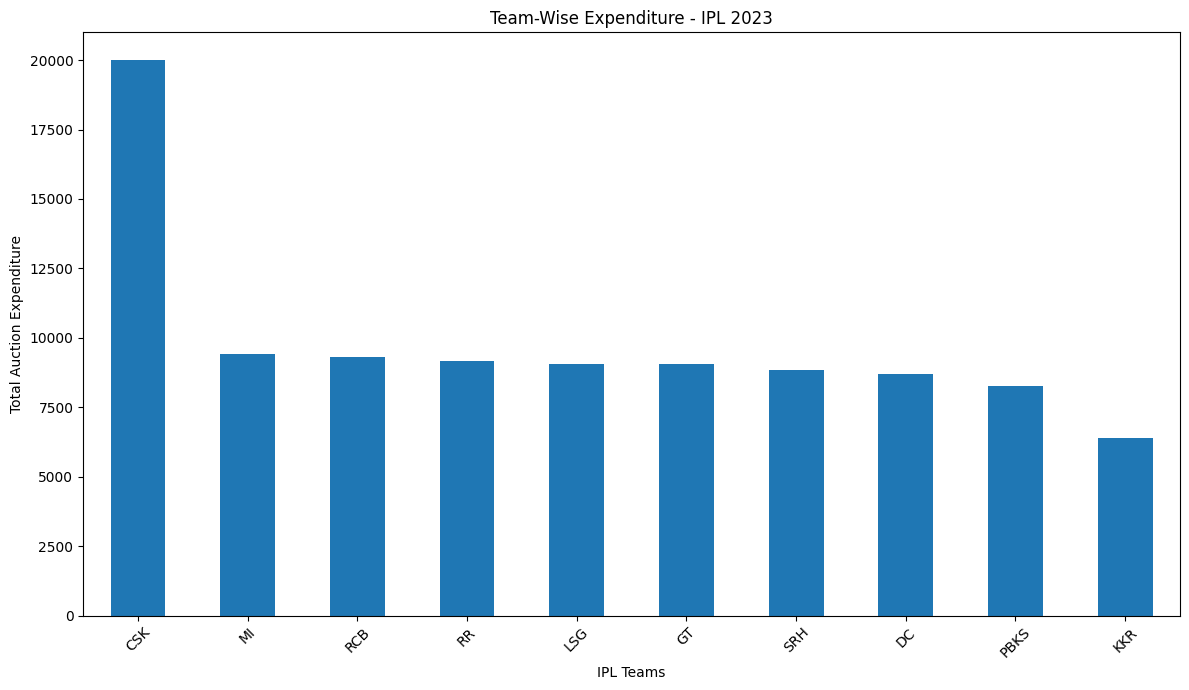

In [ ]:
plt.figure(figsize=(12,7))

team_expenditure.plot(kind="bar")

plt.title("Team-Wise Expenditure - IPL 2023")
plt.xlabel("IPL Teams")
plt.ylabel("Total Auction Expenditure")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Horizontal Bar Chart

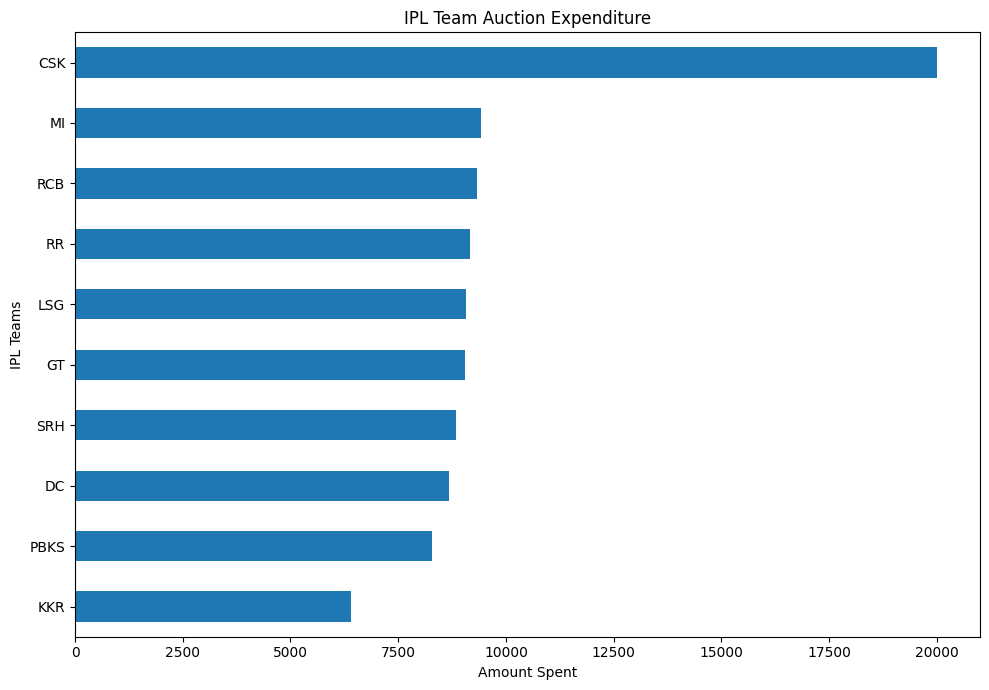

In [ ]:
plt.figure(figsize=(10,7))

team_expenditure.sort_values().plot(kind="barh")

plt.title("IPL Team Auction Expenditure")
plt.xlabel("Amount Spent")
plt.ylabel("IPL Teams")

plt.tight_layout()
plt.show()

Players Purchased by Each Team

In [ ]:
players_per_team = df["Team"].value_counts()

print("NUMBER OF PLAYERS PURCHASED BY EACH TEAM\n")
print(players_per_team)

NUMBER OF PLAYERS PURCHASED BY EACH TEAM

Team
CSK     96
RR      25
RCB     25
SRH     25
LSG     25
GT      25
DC      24
MI      23
PBKS    22
KKR     19
Name: count, dtype: int64


Players Purchased Bar Chart

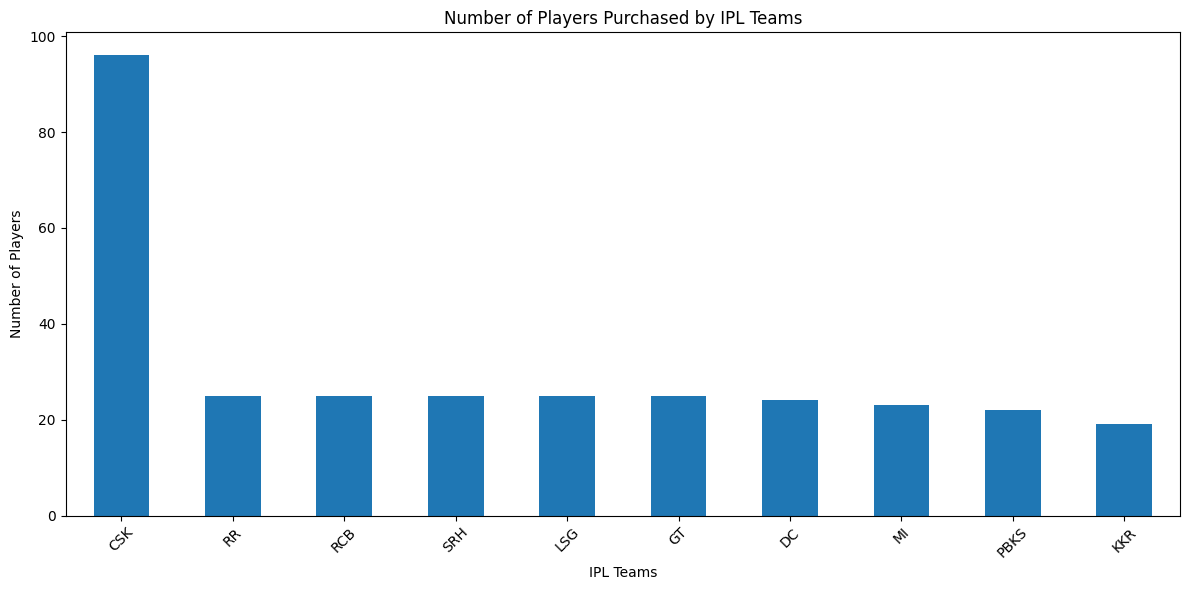

In [ ]:
plt.figure(figsize=(12,6))

players_per_team.plot(kind="bar")

plt.title("Number of Players Purchased by IPL Teams")
plt.xlabel("IPL Teams")
plt.ylabel("Number of Players")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Player Role Distribution

In [ ]:
role_distribution = df["Role"].value_counts()

print("PLAYER ROLE DISTRIBUTION\n")
print(role_distribution)

PLAYER ROLE DISTRIBUTION

Role
Bowler        111
Allrounder    103
Batter         55
WK-Batter      40
Name: count, dtype: int64


Player Role Bar Chart

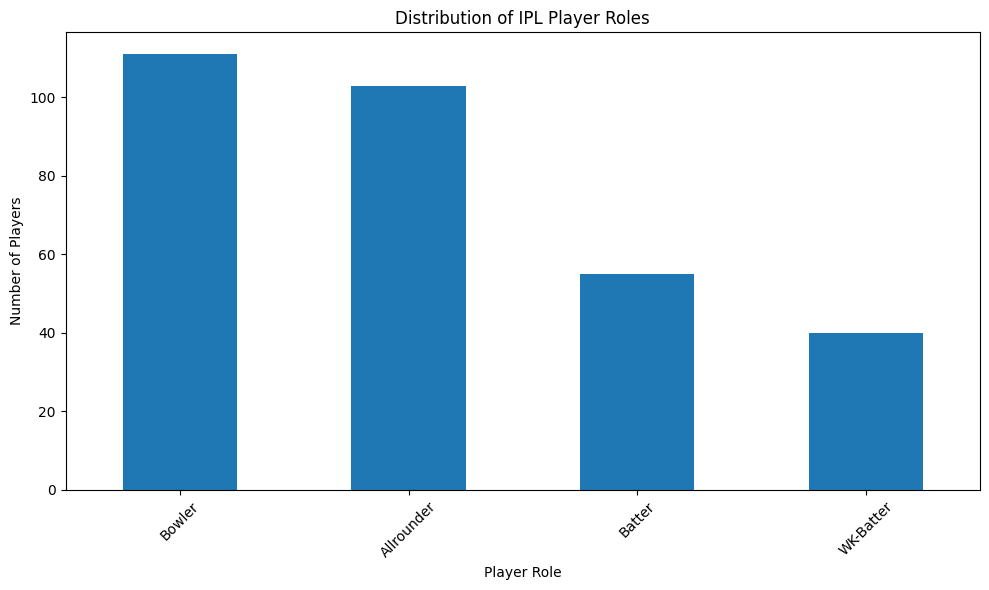

In [ ]:
plt.figure(figsize=(10,6))

role_distribution.plot(kind="bar")

plt.title("Distribution of IPL Player Roles")
plt.xlabel("Player Role")
plt.ylabel("Number of Players")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Player Role Pie Chart

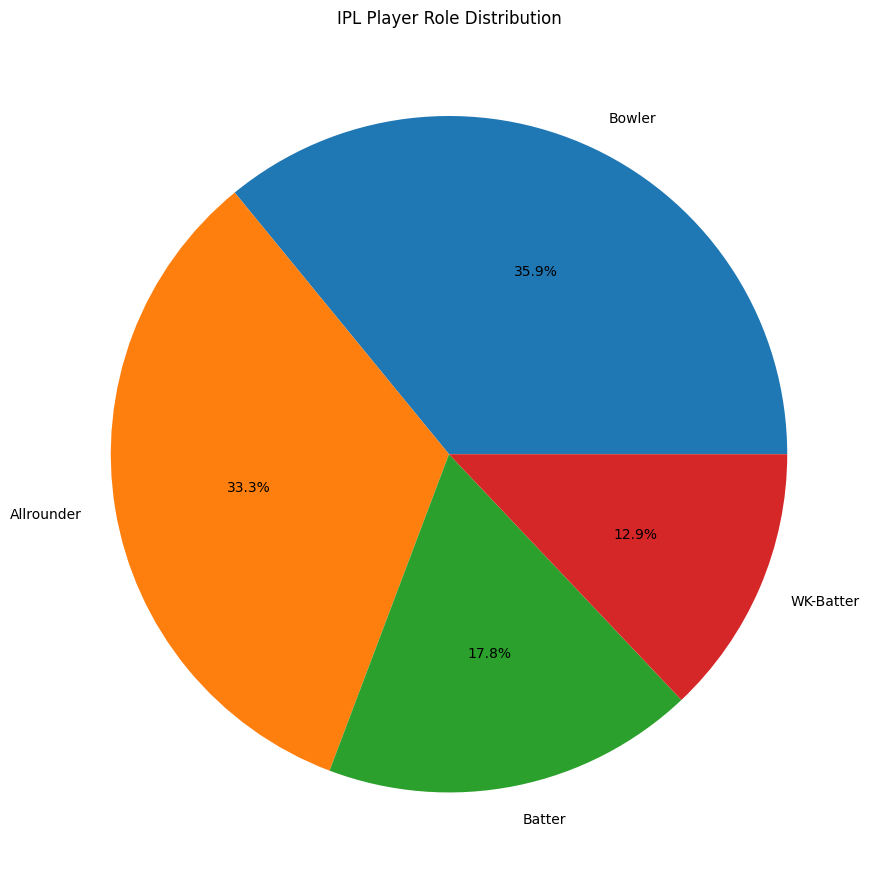

In [ ]:
plt.figure(figsize=(9,9))

role_distribution.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("IPL Player Role Distribution")
plt.ylabel("")

plt.tight_layout()
plt.show()

Sold and Unsold Players

In [ ]:
auction_status = df["Status"].value_counts()

print("SOLD AND UNSOLD PLAYERS\n")
print(auction_status)

SOLD AND UNSOLD PLAYERS

Status
RETAINED    158
SOLD         80
UNSOLD       71
Name: count, dtype: int64


Sold vs Unsold Bar Chart

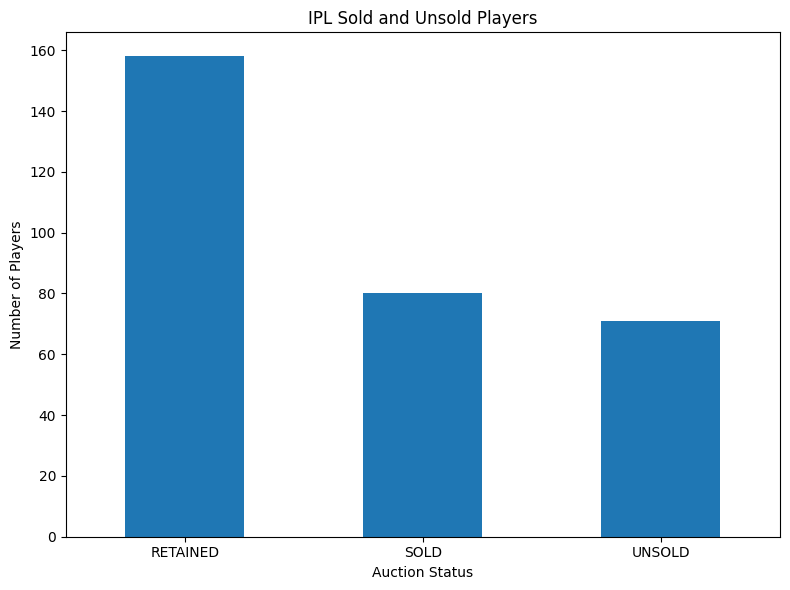

In [ ]:
plt.figure(figsize=(8,6))

auction_status.plot(kind="bar")

plt.title("IPL Sold and Unsold Players")
plt.xlabel("Auction Status")
plt.ylabel("Number of Players")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Sold vs Unsold Pie Chart

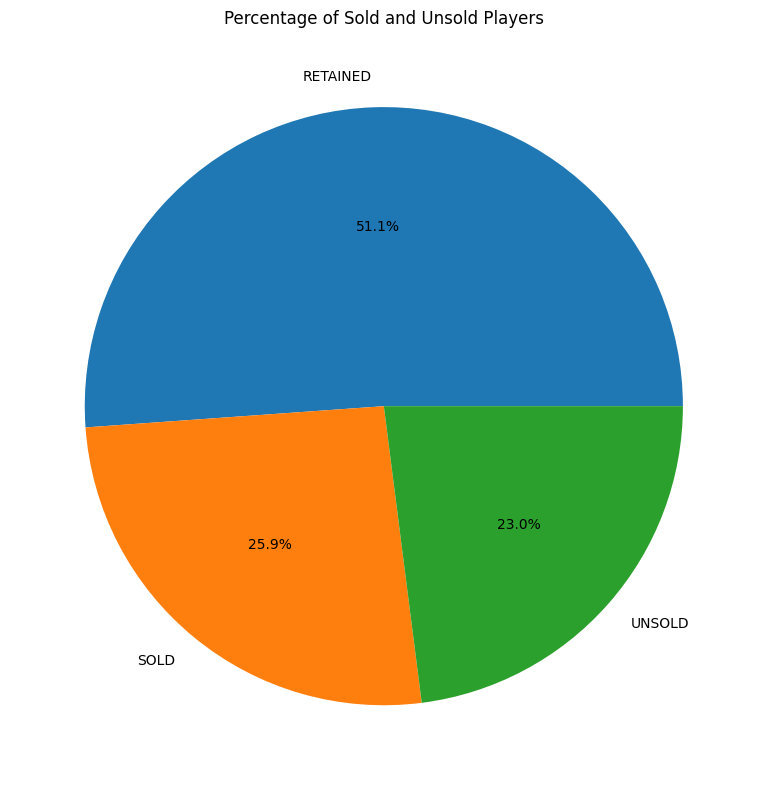

In [ ]:
plt.figure(figsize=(8,8))

auction_status.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Percentage of Sold and Unsold Players")
plt.ylabel("")

plt.tight_layout()
plt.show()

Auction Price Distribution (Histogram)

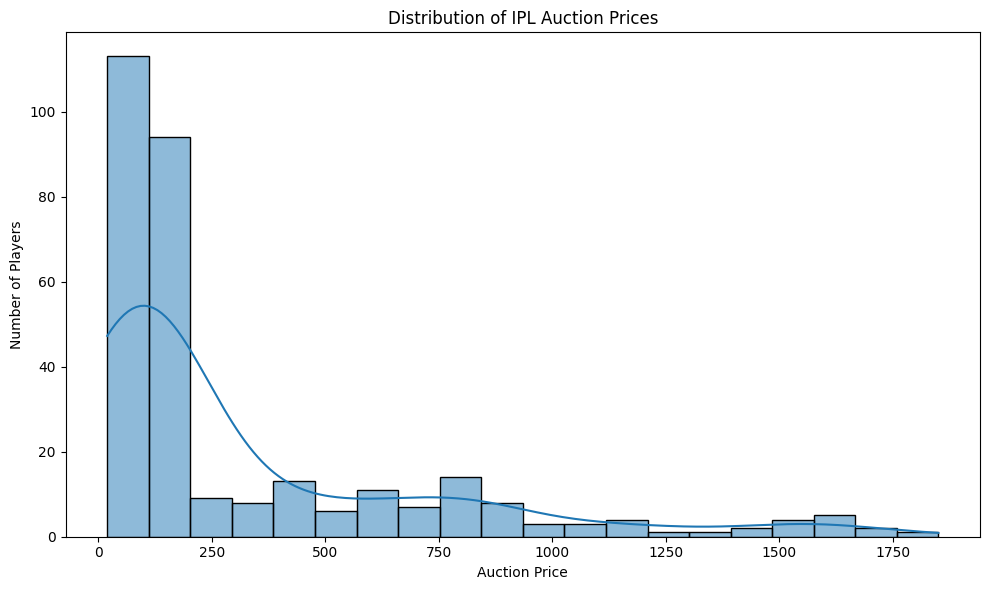

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Auction Price"],
    bins=20,
    kde=True
)

plt.title("Distribution of IPL Auction Prices")
plt.xlabel("Auction Price")
plt.ylabel("Number of Players")

plt.tight_layout()
plt.show()

Auction Price Box Plot

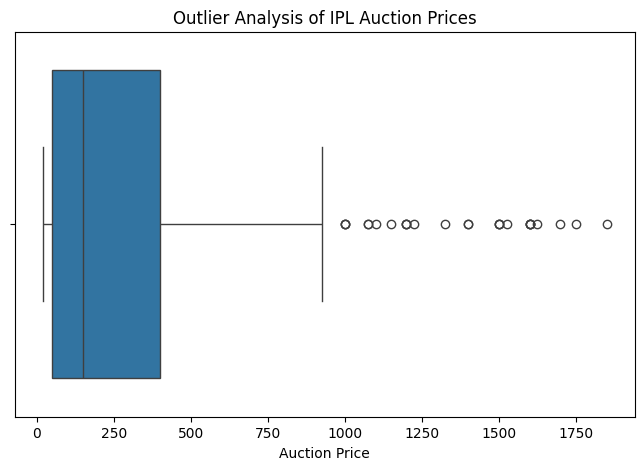

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Auction Price"]
)

plt.title("Outlier Analysis of IPL Auction Prices")
plt.xlabel("Auction Price")

plt.show()

Top 10 Most Expensive Players Chart

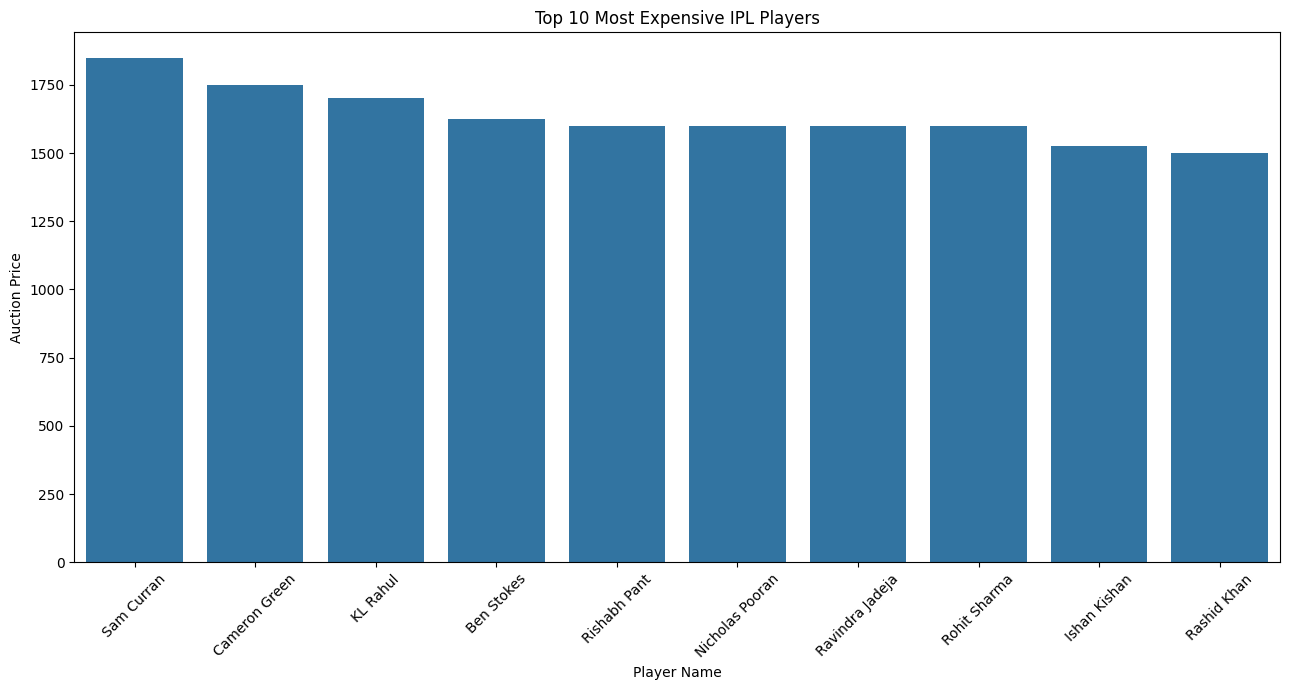

In [ ]:
top_ten_players = expensive_players.head(10)

plt.figure(figsize=(13,7))

sns.barplot(
    data=top_ten_players,
    x="Player",
    y="Auction Price"
)

plt.title("Top 10 Most Expensive IPL Players")
plt.xlabel("Player Name")
plt.ylabel("Auction Price")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Average Player Price by Team

In [ ]:
average_team_price = (
    df.groupby("Team")["Auction Price"]
    .mean()
    .sort_values(ascending=False)
)

print("AVERAGE PLAYER PRICE OF EACH TEAM\n")
print(average_team_price)

AVERAGE PLAYER PRICE OF EACH TEAM

Team
MI      409.565217
PBKS    376.363636
RCB     373.000000
RR      366.600000
LSG     362.600000
GT      362.200000
DC      361.875000
SRH     353.800000
KKR     337.368421
CSK     208.333333
Name: Auction Price, dtype: float64


Average Player Price by Team

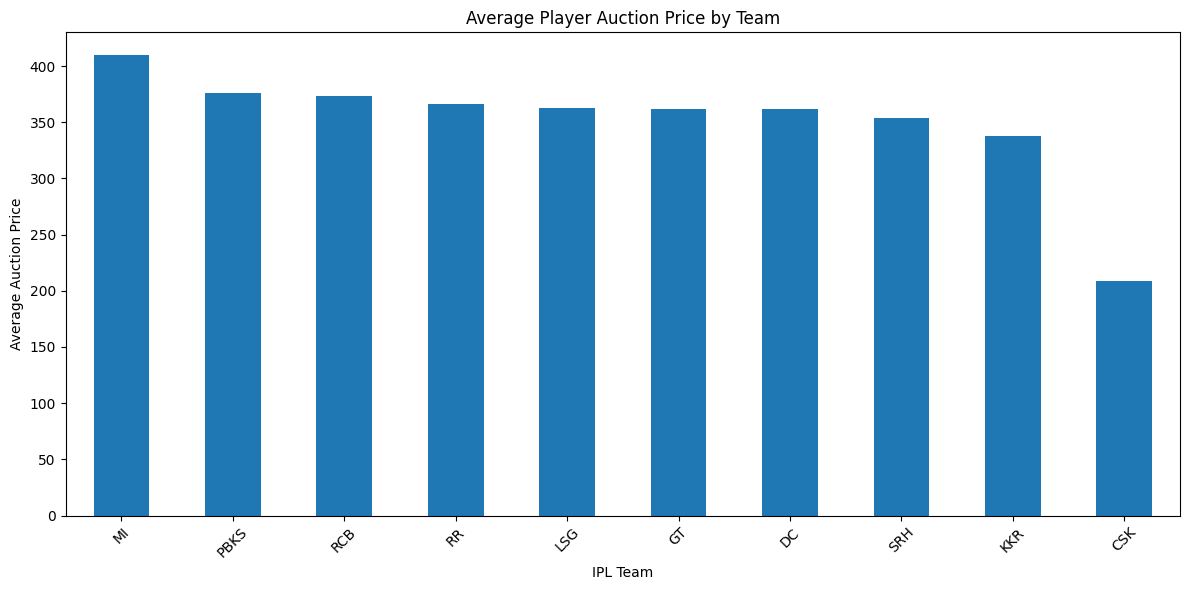

In [ ]:
plt.figure(figsize=(12,6))

average_team_price.plot(kind="bar")

plt.title("Average Player Auction Price by Team")
plt.xlabel("IPL Team")
plt.ylabel("Average Auction Price")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Role-wise Average Auction Price

In [ ]:
role_average_price = (
    df.groupby("Role")["Auction Price"]
    .mean()
    .sort_values(ascending=False)
)

print("ROLE-WISE AVERAGE AUCTION PRICE\n")
print(role_average_price)

ROLE-WISE AVERAGE AUCTION PRICE

Role
WK-Batter     404.000000
Batter        370.090909
Allrounder    319.174757
Bowler        260.000000
Name: Auction Price, dtype: float64


Role-wise Average Price Bar Chart

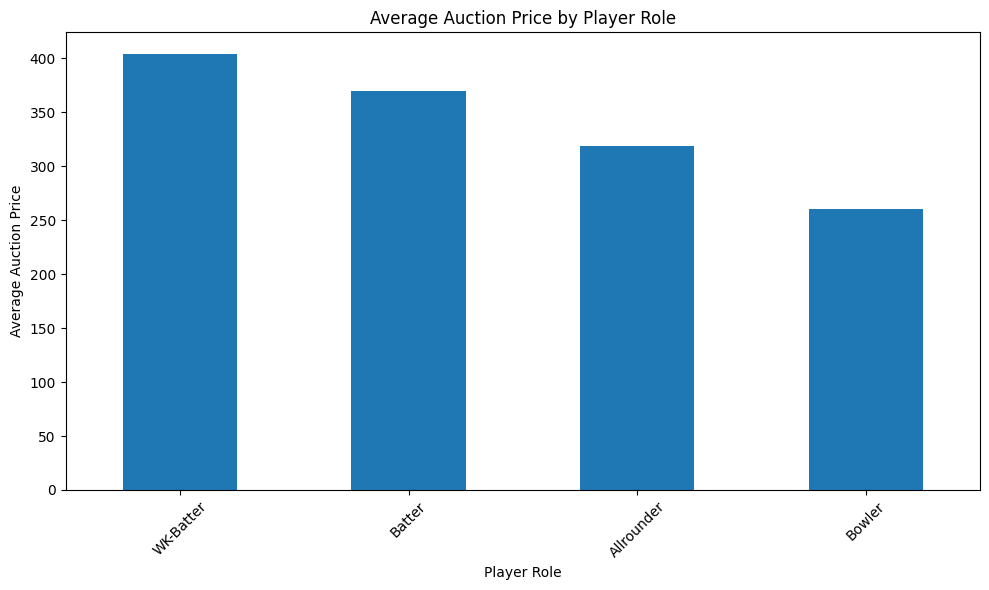

In [ ]:
plt.figure(figsize=(10,6))

role_average_price.plot(kind="bar")

plt.title("Average Auction Price by Player Role")
plt.xlabel("Player Role")
plt.ylabel("Average Auction Price")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Team and Player Role Analysis

In [ ]:
team_role_analysis = (
    df.groupby(["Team", "Role"])["Player"]
    .count()
)

print("TEAM AND PLAYER ROLE ANALYSIS\n")
print(team_role_analysis)

TEAM AND PLAYER ROLE ANALYSIS

Team  Role      
CSK   Allrounder    36
      Batter        16
      Bowler        32
      WK-Batter     12
DC    Allrounder     5
      Batter         8
      Bowler        10
      WK-Batter      1
GT    Allrounder     5
      Batter         5
      Bowler        11
      WK-Batter      4
KKR   Allrounder     8
      Batter         3
      Bowler         6
      WK-Batter      2
LSG   Allrounder    12
      Batter         1
      Bowler         9
      WK-Batter      3
MI    Allrounder     8
      Batter         5
      Bowler         7
      WK-Batter      3
PBKS  Allrounder     8
      Batter         4
      Bowler         7
      WK-Batter      3
RCB   Allrounder     8
      Batter         4
      Bowler        10
      WK-Batter      3
RR    Allrounder     5
      Batter         4
      Bowler        11
      WK-Batter      5
SRH   Allrounder     8
      Batter         5
      Bowler         8
      WK-Batter      4
Name: Player, dtype: int64


Team-wise Player Role Table

In [47]:
team_role_table = pd.pivot_table(
    df,
    values="Player",
    index="Team",
    columns="Role",
    aggfunc="count",
    fill_value=0
)

print("TEAM-WISE PLAYER ROLE TABLE\n")
print(team_role_table)

TEAM-WISE PLAYER ROLE TABLE

Role  Allrounder  Batter  Bowler  WK-Batter
Team                                       
CSK           36      16      32         12
DC             5       8      10          1
GT             5       5      11          4
KKR            8       3       6          2
LSG           12       1       9          3
MI             8       5       7          3
PBKS           8       4       7          3
RCB            8       4      10          3
RR             5       4      11          5
SRH            8       5       8          4


Team-wise Player Role Heatmap

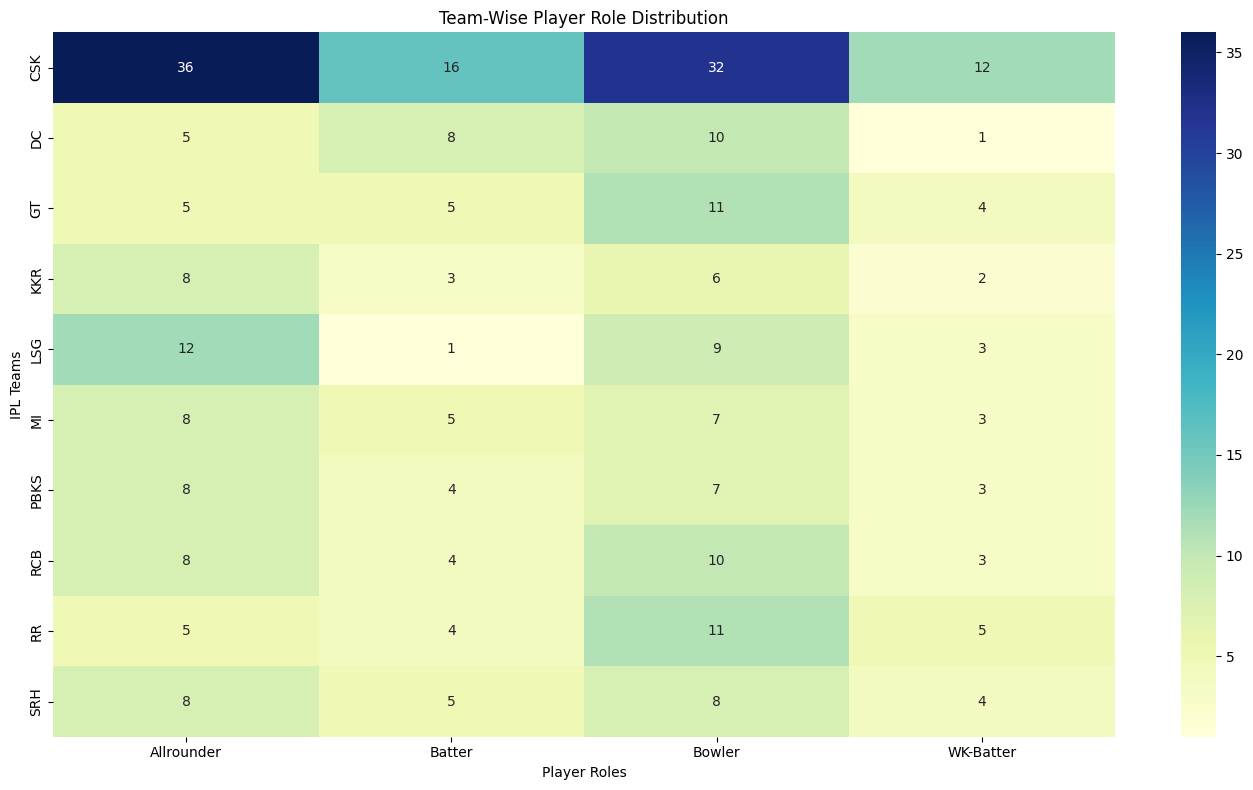

In [48]:
plt.figure(figsize=(14,8))

sns.heatmap(
    team_role_table,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Team-Wise Player Role Distribution")
plt.xlabel("Player Roles")
plt.ylabel("IPL Teams")

plt.tight_layout()
plt.show()

Correlation Matrix

In [49]:
numerical_data = df.select_dtypes(include=["int64", "float64"])

correlation = numerical_data.corr()

print("CORRELATION MATRIX\n")
print(correlation)

CORRELATION MATRIX

               Base Price  Auction Price
Base Price       1.000000       0.089089
Auction Price    0.089089       1.000000


Correlation Heatmap

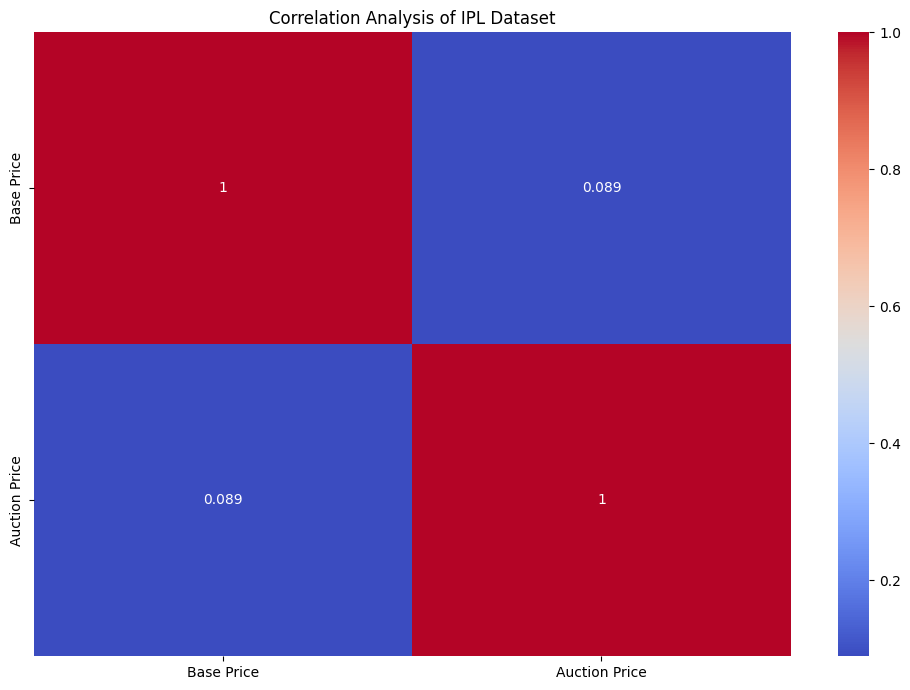

In [50]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Analysis of IPL Dataset")

plt.tight_layout()
plt.show()

Auction Price Statistics

In [51]:
print("AUCTION PRICE STATISTICS\n")

print("Maximum Auction Price :", df["Auction Price"].max())
print("Minimum Auction Price :", df["Auction Price"].min())
print("Average Auction Price :", round(df["Auction Price"].mean(), 2))
print("Median Auction Price :", df["Auction Price"].median())
print("Auction Price Standard Deviation :", round(df["Auction Price"].std(), 2))

AUCTION PRICE STATISTICS

Maximum Auction Price : 1850.0
Minimum Auction Price : 20.0
Average Auction Price : 317.96
Median Auction Price : 150.0
Auction Price Standard Deviation : 404.5


Team with Highest & Lowest Expenditure



In [52]:
print("TEAM WITH HIGHEST EXPENDITURE")
print(team_expenditure.idxmax(), ":", team_expenditure.max())

print("\nTEAM WITH LOWEST EXPENDITURE")
print(team_expenditure.idxmin(), ":", team_expenditure.min())

TEAM WITH HIGHEST EXPENDITURE
CSK : 20000.0

TEAM WITH LOWEST EXPENDITURE
KKR : 6410.0


Most Expensive IPL Player

In [53]:
highest_player = df.loc[df["Auction Price"].idxmax()]

print("MOST EXPENSIVE IPL PLAYER\n")
print(highest_player)

MOST EXPENSIVE IPL PLAYER

Player           Sam Curran
Role             Allrounder
nationality         England
Base Price            200.0
Auction Price        1850.0
Team                   PBKS
Status                 SOLD
Name: 150, dtype: object


Final Project Summary

In [54]:
print("IPL 2023 DATA ANALYSIS SUMMARY\n")

print("Total Number of Players :", len(df))
print("Total IPL Teams :", df["Team"].nunique())
print("Total Player Roles :", df["Role"].nunique())
print("Highest Auction Price :", df["Auction Price"].max())
print("Average Auction Price :", round(df["Auction Price"].mean(), 2))
print("Total Auction Expenditure :", df["Auction Price"].sum())

IPL 2023 DATA ANALYSIS SUMMARY

Total Number of Players : 309
Total IPL Teams : 10
Total Player Roles : 4
Highest Auction Price : 1850.0
Average Auction Price : 317.96
Total Auction Expenditure : 98250.0


Final Completion Message

In [55]:
print("=" * 60)
print("     IPL 2023 DATA ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 60)

     IPL 2023 DATA ANALYSIS COMPLETED SUCCESSFULLY
